
#### Some parts of this notebook are used only for visualization purposes to compare with other enviroments. Dont pay attention to it.

In [1]:
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEEDS = [0, 1, 2]
OUT_DIR = Path("poster_rl_plots")
OUT_DIR.mkdir(exist_ok=True)

# Global plot style
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.facecolor": "#f5f6f8",
    "grid.color": "#e1e5ea",
    "grid.linewidth": 0.8,
})

COLORS = {
    r"$\pi_1$": "#2ca02c",
    r"$\pi_2$": "#ff7f0e",
    r"$\pi_{\mathrm{ref}}$": "#7f7f7f",
    "DPO": "#1f77b4",
    "RLHF-PPO": "#d62728",
}

METHOD_ORDER = [r"$\pi_1$", r"$\pi_2$", r"$\pi_{\mathrm{ref}}$", "DPO", "RLHF-PPO"]

def set_panel_style(ax):
    ax.grid(True, alpha=0.8)
    ax.tick_params(axis="both", colors="#34495e")
    ax.yaxis.label.set_color("#2c3e50")
    ax.xaxis.label.set_color("#2c3e50")

def mean_std(x):
    x = np.asarray(x, dtype=float)
    return float(np.mean(x)), float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

def summarize(df, group_cols, value_col="reward"):
    return (
        df.groupby(group_cols)[value_col]
        .agg(mean="mean", std=lambda x: np.std(x, ddof=1) if len(x) > 1 else 0.0)
        .reset_index()
    )



## 1. FrozenLake implementation


In [2]:

class FrozenLake4x4:
    '''
    Deterministic 4x4 FrozenLake.
    Actions: 0=left, 1=down, 2=right, 3=up.
    Reward: 1 only when reaching the goal, later plotted as reward*100.
    '''
    desc = np.array(list(map(list, ["SFFF", "FHFH", "FFFH", "HFFG"])))
    nrow, ncol = 4, 4
    nS, nA = 16, 4
    terminal_tiles = {"H", "G"}

    def __init__(self, max_steps=100):
        self.max_steps = max_steps
        self.rng = np.random.default_rng(0)
        self.P = self._build_transition_table()
        self.reset()

    def to_s(self, row, col):
        return row * self.ncol + col

    def from_s(self, s):
        return divmod(s, self.ncol)

    def _move(self, row, col, action):
        if action == 0:
            col = max(col - 1, 0)
        elif action == 1:
            row = min(row + 1, self.nrow - 1)
        elif action == 2:
            col = min(col + 1, self.ncol - 1)
        elif action == 3:
            row = max(row - 1, 0)
        return row, col

    def _build_transition_table(self):
        P = {s: {a: [] for a in range(self.nA)} for s in range(self.nS)}
        for s in range(self.nS):
            row, col = self.from_s(s)
            tile = self.desc[row, col]
            for a in range(self.nA):
                if tile in self.terminal_tiles:
                    P[s][a].append((1.0, s, 0.0, True))
                else:
                    nr, nc = self._move(row, col, a)
                    ns = self.to_s(nr, nc)
                    ntile = self.desc[nr, nc]
                    done = ntile in self.terminal_tiles
                    reward = 1.0 if ntile == "G" else 0.0
                    P[s][a].append((1.0, ns, reward, done))
        return P

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.s = 0
        self.steps = 0
        self.done = False
        return self.s

    def step(self, action):
        if self.done:
            return self.s, 0.0, True, {}
        transitions = self.P[self.s][action]
        idx = self.rng.choice(len(transitions), p=[x[0] for x in transitions])
        _, ns, reward, done = transitions[idx]
        self.s = ns
        self.steps += 1
        if self.steps >= self.max_steps:
            done = True
        self.done = done
        return ns, reward, done, {}

def value_iteration(env, gamma=0.99, tol=1e-10, max_iter=10_000):
    V = np.zeros(env.nS)
    for _ in range(max_iter):
        old = V.copy()
        Q = np.zeros((env.nS, env.nA))
        for s in range(env.nS):
            for a in range(env.nA):
                Q[s, a] = sum(
                    p * (r + gamma * old[ns] * (not done))
                    for p, ns, r, done in env.P[s][a]
                )
        V = Q.max(axis=1)
        if np.max(np.abs(V - old)) < tol:
            break

    Q = np.zeros((env.nS, env.nA))
    for s in range(env.nS):
        for a in range(env.nA):
            Q[s, a] = sum(
                p * (r + gamma * V[ns] * (not done))
                for p, ns, r, done in env.P[s][a]
            )
    return V, Q

def epsilon_greedy_policy(Q, eps):
    nS, nA = Q.shape
    probs = np.ones((nS, nA), dtype=float) * eps / nA
    best = np.argmax(Q, axis=1)
    probs[np.arange(nS), best] += 1.0 - eps
    return probs

def softmax_np(logits, axis=-1):
    z = logits - np.max(logits, axis=axis, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=axis, keepdims=True)

def rollout(policy_probs, seed, max_steps=100):
    env = FrozenLake4x4(max_steps=max_steps)
    s = env.reset(seed=seed)
    states, actions, rewards = [], [], []
    total = 0.0

    for _ in range(max_steps):
        a = env.rng.choice(env.nA, p=policy_probs[s])
        ns, r, done, _ = env.step(a)
        states.append(s)
        actions.append(a)
        rewards.append(r)
        total += r
        s = ns
        if done:
            break

    return {
        "states": np.asarray(states, dtype=np.int64),
        "actions": np.asarray(actions, dtype=np.int64),
        "rewards": np.asarray(rewards, dtype=float),
        "return": float(total),
    }

def evaluate_policy(policy_probs, episodes=500, seed=0):
    rewards = [
        100.0 * rollout(policy_probs, seed=seed + i)["return"]
        for i in range(episodes)
    ]
    return float(np.mean(rewards)), float(np.std(rewards, ddof=1))



## 2. Preference data + DPO + lightweight RLHF-PPO

For FrozenLake, preferences are generated by comparing rollouts from a stronger policy `π1` and a weaker policy `π2`.
DPO is trained directly on trajectory preferences.

The RLHF-PPO block first fits a tabular reward model from preferences and then optimizes a tabular policy with a clipped PPO-style update plus a β-weighted pull toward the reference policy.


In [3]:

def traj_counts(states, actions, nS=16, nA=4):
    idx = states * nA + actions
    return np.bincount(idx, minlength=nS * nA).astype(float)

def generate_preference_counts(pi_good, pi_bad, K, seed=0, max_steps=100):
    rng = np.random.default_rng(seed)
    wins, loses = [], []
    attempts = 0

    while len(wins) < K and attempts < 100 * K:
        attempts += 1
        t1 = rollout(pi_good, seed=int(rng.integers(2**31 - 1)), max_steps=max_steps)
        t2 = rollout(pi_bad, seed=int(rng.integers(2**31 - 1)), max_steps=max_steps)

        # Skip ties to keep the preference signal clean.
        if t1["return"] == t2["return"]:
            continue

        if t1["return"] > t2["return"]:
            winner, loser = t1, t2
        else:
            winner, loser = t2, t1

        wins.append(traj_counts(winner["states"], winner["actions"]))
        loses.append(traj_counts(loser["states"], loser["actions"]))

    if len(wins) < K:
        raise RuntimeError(f"Generated only {len(wins)} preferences out of requested K={K}.")

    return np.stack(wins), np.stack(loses)

class AdamNumpy:
    def __init__(self, shape, lr=0.05, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0
        self.m = np.zeros(shape)
        self.v = np.zeros(shape)

    def step(self, params, grad):
        self.t += 1
        self.m = self.beta1 * self.m + (1.0 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1.0 - self.beta2) * (grad ** 2)
        mhat = self.m / (1.0 - self.beta1 ** self.t)
        vhat = self.v / (1.0 - self.beta2 ** self.t)
        return params - self.lr * mhat / (np.sqrt(vhat) + self.eps)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

def log_softmax_np(logits):
    z = logits - np.max(logits, axis=1, keepdims=True)
    return z - np.log(np.sum(np.exp(z), axis=1, keepdims=True))

def grad_logsoftmax_from_grad_logp(grad_logp, probs):
    '''
    Convert dL/dlog_probs to dL/dlogits, row-wise.
    '''
    grad = np.zeros_like(grad_logp)
    for s in range(grad_logp.shape[0]):
        grad[s] = grad_logp[s] - probs[s] * np.sum(grad_logp[s])
    return grad

def train_dpo(Cw, Cl, ref_probs, beta=1.0, seed=0, epochs=500, lr=0.08, batch_size=128):
    rng = np.random.default_rng(seed)
    Cdiff = Cw - Cl
    nS, nA = ref_probs.shape
    n = Cdiff.shape[0]

    logits = np.log(ref_probs + 1e-8)
    opt = AdamNumpy(logits.shape, lr=lr)

    ref_logp = np.log(ref_probs.reshape(-1) + 1e-8)
    ref_lr = Cdiff @ ref_logp
    losses = []

    for _ in range(epochs):
        idx = rng.choice(n, size=min(batch_size, n), replace=False)
        batch = Cdiff[idx]

        logp = log_softmax_np(logits)
        probs = np.exp(logp)
        pi_lr = batch @ logp.reshape(-1)
        z = beta * (pi_lr - ref_lr[idx])

        loss = -np.mean(np.log(sigmoid(z) + 1e-8))
        losses.append(loss)

        # d loss / d z = sigmoid(z) - 1
        coeff = beta * (sigmoid(z) - 1.0) / len(idx)
        grad_logp_flat = coeff @ batch
        grad_logp = grad_logp_flat.reshape(nS, nA)
        grad_logits = grad_logsoftmax_from_grad_logp(grad_logp, probs)

        logits = opt.step(logits, grad_logits)

    return softmax_np(logits), losses

def train_reward_model(Cw, Cl, seed=0, epochs=500, lr=0.05, batch_size=128):
    rng = np.random.default_rng(seed)
    Cdiff = Cw - Cl
    n = Cdiff.shape[0]
    reward = np.zeros(Cdiff.shape[1], dtype=float)
    opt = AdamNumpy(reward.shape, lr=lr)
    losses = []

    for _ in range(epochs):
        idx = rng.choice(n, size=min(batch_size, n), replace=False)
        batch = Cdiff[idx]
        z = batch @ reward
        loss = -np.mean(np.log(sigmoid(z) + 1e-8))
        losses.append(loss)

        coeff = (sigmoid(z) - 1.0) / len(idx)
        grad = coeff @ batch
        reward = opt.step(reward, grad)

    return reward.reshape(16, 4), losses

def discounted_returns(rewards, gamma=0.99):
    out = []
    G = 0.0
    for r in rewards[::-1]:
        G = float(r) + gamma * G
        out.append(G)
    return np.asarray(out[::-1], dtype=float)

def train_rlhf_ppo(
    reward_table,
    ref_probs,
    beta_kl=0.03,
    seed=0,
    updates=150,
    episodes_per_update=16,
    epochs_per_update=3,
    lr=0.03,
    gamma=0.99,
    clip_eps=0.2,
):
    '''
    Lightweight tabular PPO-style optimizer:
    - collect rollouts under old policy
    - use learned reward model for returns
    - clipped importance-ratio policy gradient
    - beta_kl pulls logits toward log(reference policy)
    '''
    rng = np.random.default_rng(seed)
    nS, nA = ref_probs.shape
    logits = np.log(ref_probs + 1e-8)
    ref_logits = np.log(ref_probs + 1e-8)

    losses = []

    for _ in range(updates):
        old_probs = softmax_np(logits)

        batch_s, batch_a, batch_oldp, batch_adv = [], [], [], []
        for _ep in range(episodes_per_update):
            traj = rollout(old_probs, seed=int(rng.integers(2**31 - 1)))
            s = traj["states"]
            a = traj["actions"]
            learned_rewards = reward_table[s, a]
            ret = discounted_returns(learned_rewards, gamma=gamma)

            batch_s.append(s)
            batch_a.append(a)
            batch_oldp.append(old_probs[s, a])
            batch_adv.append(ret)

        states = np.concatenate(batch_s)
        actions = np.concatenate(batch_a)
        old_action_probs = np.concatenate(batch_oldp)
        adv = np.concatenate(batch_adv)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        for _epoch in range(epochs_per_update):
            probs = softmax_np(logits)
            grad = np.zeros_like(logits)
            approx_obj = 0.0

            for s, a, oldp, A in zip(states, actions, old_action_probs, adv):
                p = probs[s, a]
                ratio = p / (oldp + 1e-8)

                # If the clipped objective is active, skip the policy-gradient term.
                clipped = (A > 0 and ratio > 1 + clip_eps) or (A < 0 and ratio < 1 - clip_eps)
                used_ratio = np.clip(ratio, 1 - clip_eps, 1 + clip_eps)
                approx_obj += min(ratio * A, used_ratio * A)

                if not clipped:
                    onehot = np.zeros(nA)
                    onehot[a] = 1.0
                    grad[s] += (ratio * A) * (onehot - probs[s])

            grad /= max(1, len(states))

            # KL-style beta regularization toward the reference logits.
            grad -= beta_kl * (logits - ref_logits)

            logits += lr * grad
            losses.append(float(approx_obj / max(1, len(states))))

    return softmax_np(logits), losses



## 3. Run FrozenLake with 3 seeds

The run is cached to CSV.


In [4]:

FORCE_RERUN = True

FROZENLAKE_CACHE = OUT_DIR / "frozenlake_3seed_results.csv"

K_VALUES_FL = [50, 100, 200, 500]
BETA_VALUES_FL = [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]

DEFAULT_K = 200
DEFAULT_DPO_BETA = 0.1
DEFAULT_PPO_BETA = 0.03

EVAL_EPISODES = 500

def make_base_policies():
    env = FrozenLake4x4()
    _, Q = value_iteration(env)

    pi1 = epsilon_greedy_policy(Q, eps=0.01)   # strong policy
    pi2 = epsilon_greedy_policy(Q, eps=0.20)   # weaker preference-source policy
    pi_ref = epsilon_greedy_policy(Q, eps=0.10) # reference policy

    return pi1, pi2, pi_ref

def run_frozenlake_all():
    pi1, pi2, pi_ref = make_base_policies()
    rows = []

    for seed in SEEDS:
        print(f"Seed {seed}")

        # Baselines
        for name, policy in [
            (r"$\pi_1$", pi1),
            (r"$\pi_2$", pi2),
            (r"$\pi_{\mathrm{ref}}$", pi_ref),
        ]:
            m, _ = evaluate_policy(policy, episodes=EVAL_EPISODES, seed=10_000 * seed)
            rows.append({
                "env": "FrozenLake",
                "panel": "comparison",
                "method": name,
                "seed": seed,
                "K": np.nan,
                "beta": np.nan,
                "reward": m,
            })

        # Default preference set for comparison and beta sweep
        Cw_default, Cl_default = generate_preference_counts(
            pi1, pi2, K=DEFAULT_K, seed=seed
        )

        # DPO default
        dpo_policy, _ = train_dpo(
            Cw_default, Cl_default, pi_ref,
            beta=DEFAULT_DPO_BETA, seed=seed
        )
        m, _ = evaluate_policy(dpo_policy, episodes=EVAL_EPISODES, seed=20_000 * seed + 1)
        rows.append({
            "env": "FrozenLake",
            "panel": "comparison",
            "method": "DPO",
            "seed": seed,
            "K": DEFAULT_K,
            "beta": DEFAULT_DPO_BETA,
            "reward": m,
        })

        # RLHF-PPO default
        reward_model, _ = train_reward_model(Cw_default, Cl_default, seed=seed)
        ppo_policy, _ = train_rlhf_ppo(
            reward_model, pi_ref,
            beta_kl=DEFAULT_PPO_BETA, seed=seed
        )
        m, _ = evaluate_policy(ppo_policy, episodes=EVAL_EPISODES, seed=30_000 * seed + 1)
        rows.append({
            "env": "FrozenLake",
            "panel": "comparison",
            "method": "RLHF-PPO",
            "seed": seed,
            "K": DEFAULT_K,
            "beta": DEFAULT_PPO_BETA,
            "reward": m,
        })

        # K sweep
        for K in K_VALUES_FL:
            Cw, Cl = generate_preference_counts(pi1, pi2, K=K, seed=seed + 1000 + K)

            dpo_policy, _ = train_dpo(
                Cw, Cl, pi_ref,
                beta=DEFAULT_DPO_BETA, seed=seed + K
            )
            m, _ = evaluate_policy(dpo_policy, episodes=EVAL_EPISODES, seed=40_000 * seed + K)
            rows.append({
                "env": "FrozenLake",
                "panel": "K",
                "method": "DPO",
                "seed": seed,
                "K": K,
                "beta": DEFAULT_DPO_BETA,
                "reward": m,
            })

            reward_model_k, _ = train_reward_model(Cw, Cl, seed=seed + K)
            ppo_policy, _ = train_rlhf_ppo(
                reward_model_k, pi_ref,
                beta_kl=DEFAULT_PPO_BETA, seed=seed + K
            )
            m, _ = evaluate_policy(ppo_policy, episodes=EVAL_EPISODES, seed=50_000 * seed + K)
            rows.append({
                "env": "FrozenLake",
                "panel": "K",
                "method": "RLHF-PPO",
                "seed": seed,
                "K": K,
                "beta": DEFAULT_PPO_BETA,
                "reward": m,
            })

        # Beta sweep for both DPO and RLHF-PPO
        for beta in BETA_VALUES_FL:
            dpo_policy, _ = train_dpo(
                Cw_default, Cl_default, pi_ref,
                beta=beta, seed=seed + int(beta * 10000)
            )
            m, _ = evaluate_policy(dpo_policy, episodes=EVAL_EPISODES, seed=60_000 * seed + int(beta * 1e6))
            rows.append({
                "env": "FrozenLake",
                "panel": "beta",
                "method": "DPO",
                "seed": seed,
                "K": DEFAULT_K,
                "beta": beta,
                "reward": m,
            })

            ppo_policy, _ = train_rlhf_ppo(
                reward_model, pi_ref,
                beta_kl=beta, seed=seed + int(beta * 10000)
            )
            m, _ = evaluate_policy(ppo_policy, episodes=EVAL_EPISODES, seed=70_000 * seed + int(beta * 1e6))
            rows.append({
                "env": "FrozenLake",
                "panel": "beta",
                "method": "RLHF-PPO",
                "seed": seed,
                "K": DEFAULT_K,
                "beta": beta,
                "reward": m,
            })

    return pd.DataFrame(rows)

if FORCE_RERUN or not FROZENLAKE_CACHE.exists():
    frozenlake_df = run_frozenlake_all()
    frozenlake_df.to_csv(FROZENLAKE_CACHE, index=False)
else:
    frozenlake_df = pd.read_csv(FROZENLAKE_CACHE)

frozenlake_df.head()


Seed 0
Seed 1
Seed 2


,env,panel,method,seed,K,beta,reward
0,FrozenLake,comparison,$\pi_1$,0,NaN,NaN,98.8
1,FrozenLake,comparison,$\pi_2$,0,NaN,NaN,79.8
2,FrozenLake,comparison,$\pi_{\mathrm{ref}}$,0,NaN,NaN,91.4
3,FrozenLake,comparison,DPO,0,200.0,0.10,100.0
4,FrozenLake,comparison,RLHF-PPO,0,200.0,0.03,92.0


### Only for visualization purposes.

In [5]:
digitized = {
    "MountainCarContinuous": {
        "comparison": pd.DataFrame({
            "method": [r"$\pi_1$", r"$\pi_2$", "DPO", "RLHF-PPO"],
            "mean":   [-156.0, -399.0, -390.0, -219.0],
            "std":    [   3.0,    5.0,    4.0,    7.0],
        }),
        "K": {
            "x": np.array([1000, 2000, 10000], dtype=float),
            "series": {
                r"$\pi_1$":       {"mean": np.array([-157.0, -157.0, -157.0]), "std": np.array([2.0, 2.0, 2.0])},
                r"$\pi_2$":       {"mean": np.array([-398.0, -398.0, -398.0]), "std": np.array([4.0, 4.0, 4.0])},
                "DPO":            {"mean": np.array([-390.0, -390.0, -389.0]), "std": np.array([4.0, 4.0, 5.0])},
                "RLHF-PPO":       {"mean": np.array([-433.0, -342.0, -219.0]), "std": np.array([15.0, 116.0, 10.0])},
            },
        },
        "beta": {
            "x": np.array([0.003, 0.01, 0.03, 0.1, 0.3, 1.0], dtype=float),
            "series": {
                "DPO": {"mean": np.array([-390.1, -390.0, -389.9, -389.7, -389.7, -390.3]),
                        "std":  np.array([4.3, 4.4, 4.1, 3.8, 3.6, 4.2])},
                r"$\pi_2$": {"mean": np.array([-397.8] * 6), "std": np.array([6.5] * 6)},
            },
        },
    },

    "Pendulum": {
        "comparison": pd.DataFrame({
            "method": [r"$\pi_1$", r"$\pi_2$", r"$\pi_{\mathrm{ref}}$", "DPO", "RLHF-PPO"],
            "mean":   [98.8, 53.0, 89.0, 94.6, 94.0],
            "std":    [ 0.2, 30.0,  2.5,  1.5,  3.0],
        }),
        "K": {
            "x": np.array([100, 200, 500, 2000], dtype=float),
            "series": {
                "DPO":      {"mean": np.array([92.1, 95.65, 95.85, 95.45]), "std": np.array([0.70, 0.40, 0.10, 0.07])},
                "RLHF-PPO": {"mean": np.array([93.9, 94.60, 95.45, 94.90]), "std": np.array([1.10, 0.10, 0.45, 0.55])},
            },
        },
        "beta": {
            "x": np.array([1e-8, 1e-3, 1e-2, 5e-2, 5e-1, 5.0, 1e2], dtype=float),
            "series": {
                "DPO":      {"mean": np.array([90.4, 95.2, 95.65, 95.65, 95.80, 95.90, 91.8]),
                             "std":  np.array([0.25, 0.25, 0.15, 0.10, 0.08, 0.08, 0.15])},
                "RLHF-PPO": {"mean": np.array([95.4, 91.5, 89.5, 87.2, 85.9, 86.8, 85.8]),
                             "std":  np.array([0.35, 0.35, 0.45, 0.65, 1.00, 0.35, 1.25])},
            },
        },
    },
}


In [6]:

def plot_comparison(ax, summary_df, title, ylabel="Reward"):
    summary_df = summary_df.copy()
    present = summary_df["method"].tolist()
    ordered = [m for m in METHOD_ORDER if m in present] + [m for m in present if m not in METHOD_ORDER]
    summary_df["method"] = pd.Categorical(summary_df["method"], categories=ordered, ordered=True)
    summary_df = summary_df.sort_values("method")

    methods = summary_df["method"].astype(str).tolist()
    x = np.arange(len(methods))
    y = summary_df["mean"].to_numpy(float)
    err = summary_df["std"].fillna(0).to_numpy(float)

    for i, method in enumerate(methods):
        color = COLORS.get(method, "#1f77b4")
        ax.errorbar(
            x[i], y[i], yerr=err[i],
            fmt="o", color=color, ecolor=color,
            capsize=3, markersize=5, linewidth=1.6
        )

    ax.set_xticks(x)
    ax.set_xticklabels(methods, fontweight="bold")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    set_panel_style(ax)

def plot_sweep(ax, x, series, title, xlabel, ylabel="Reward", logx=False, reference_as_band=True):
    for name, vals in series.items():
        mean = np.asarray(vals["mean"], dtype=float)
        std = np.asarray(vals.get("std", np.zeros_like(mean)), dtype=float)
        color = COLORS.get(name, "#1f77b4")

        is_reference = name.startswith(r"$\pi") and np.allclose(mean, mean[0])

        if is_reference and reference_as_band:
            ax.axhline(mean[0], color=color, linestyle="--", linewidth=1.2, alpha=0.8, label=name)
            if np.any(std > 0):
                ax.fill_between(
                    x, mean - std, mean + std,
                    color=color, alpha=0.08, linewidth=0
                )
        else:
            ax.errorbar(
                x, mean, yerr=std,
                marker="o", markersize=4, linewidth=1.5,
                capsize=2.5, color=color, label=name
            )

    if logx:
        ax.set_xscale("log")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    set_panel_style(ax)
    ax.legend(frameon=True, framealpha=0.9, loc="best")

def frozenlake_summaries(frozenlake_df):
    cmp_df = frozenlake_df[frozenlake_df["panel"] == "comparison"].copy()
    cmp_sum = summarize(cmp_df, ["method"])

    k_df = frozenlake_df[frozenlake_df["panel"] == "K"].copy()
    k_sum = summarize(k_df, ["method", "K"])

    beta_df = frozenlake_df[frozenlake_df["panel"] == "beta"].copy()
    beta_sum = summarize(beta_df, ["method", "beta"])

    # Add FrozenLake baseline reference bands to K sweep
    base_sum = cmp_sum.set_index("method")
    k_x = np.asarray(K_VALUES_FL, dtype=float)
    k_series = {}
    for ref_name in [r"$\pi_1$", r"$\pi_2$", r"$\pi_{\mathrm{ref}}$"]:
        k_series[ref_name] = {
            "mean": np.repeat(base_sum.loc[ref_name, "mean"], len(k_x)),
            "std":  np.repeat(base_sum.loc[ref_name, "std"], len(k_x)),
        }

    for method in ["DPO", "RLHF-PPO"]:
        sub = k_sum[k_sum["method"] == method].sort_values("K")
        k_series[method] = {
            "mean": sub["mean"].to_numpy(float),
            "std": sub["std"].to_numpy(float),
        }

    beta_x = np.asarray(BETA_VALUES_FL, dtype=float)
    beta_series = {}
    for method in ["DPO", "RLHF-PPO"]:
        sub = beta_sum[beta_sum["method"] == method].sort_values("beta")
        beta_series[method] = {
            "mean": sub["mean"].to_numpy(float),
            "std": sub["std"].to_numpy(float),
        }

    return cmp_sum, k_x, k_series, beta_x, beta_series


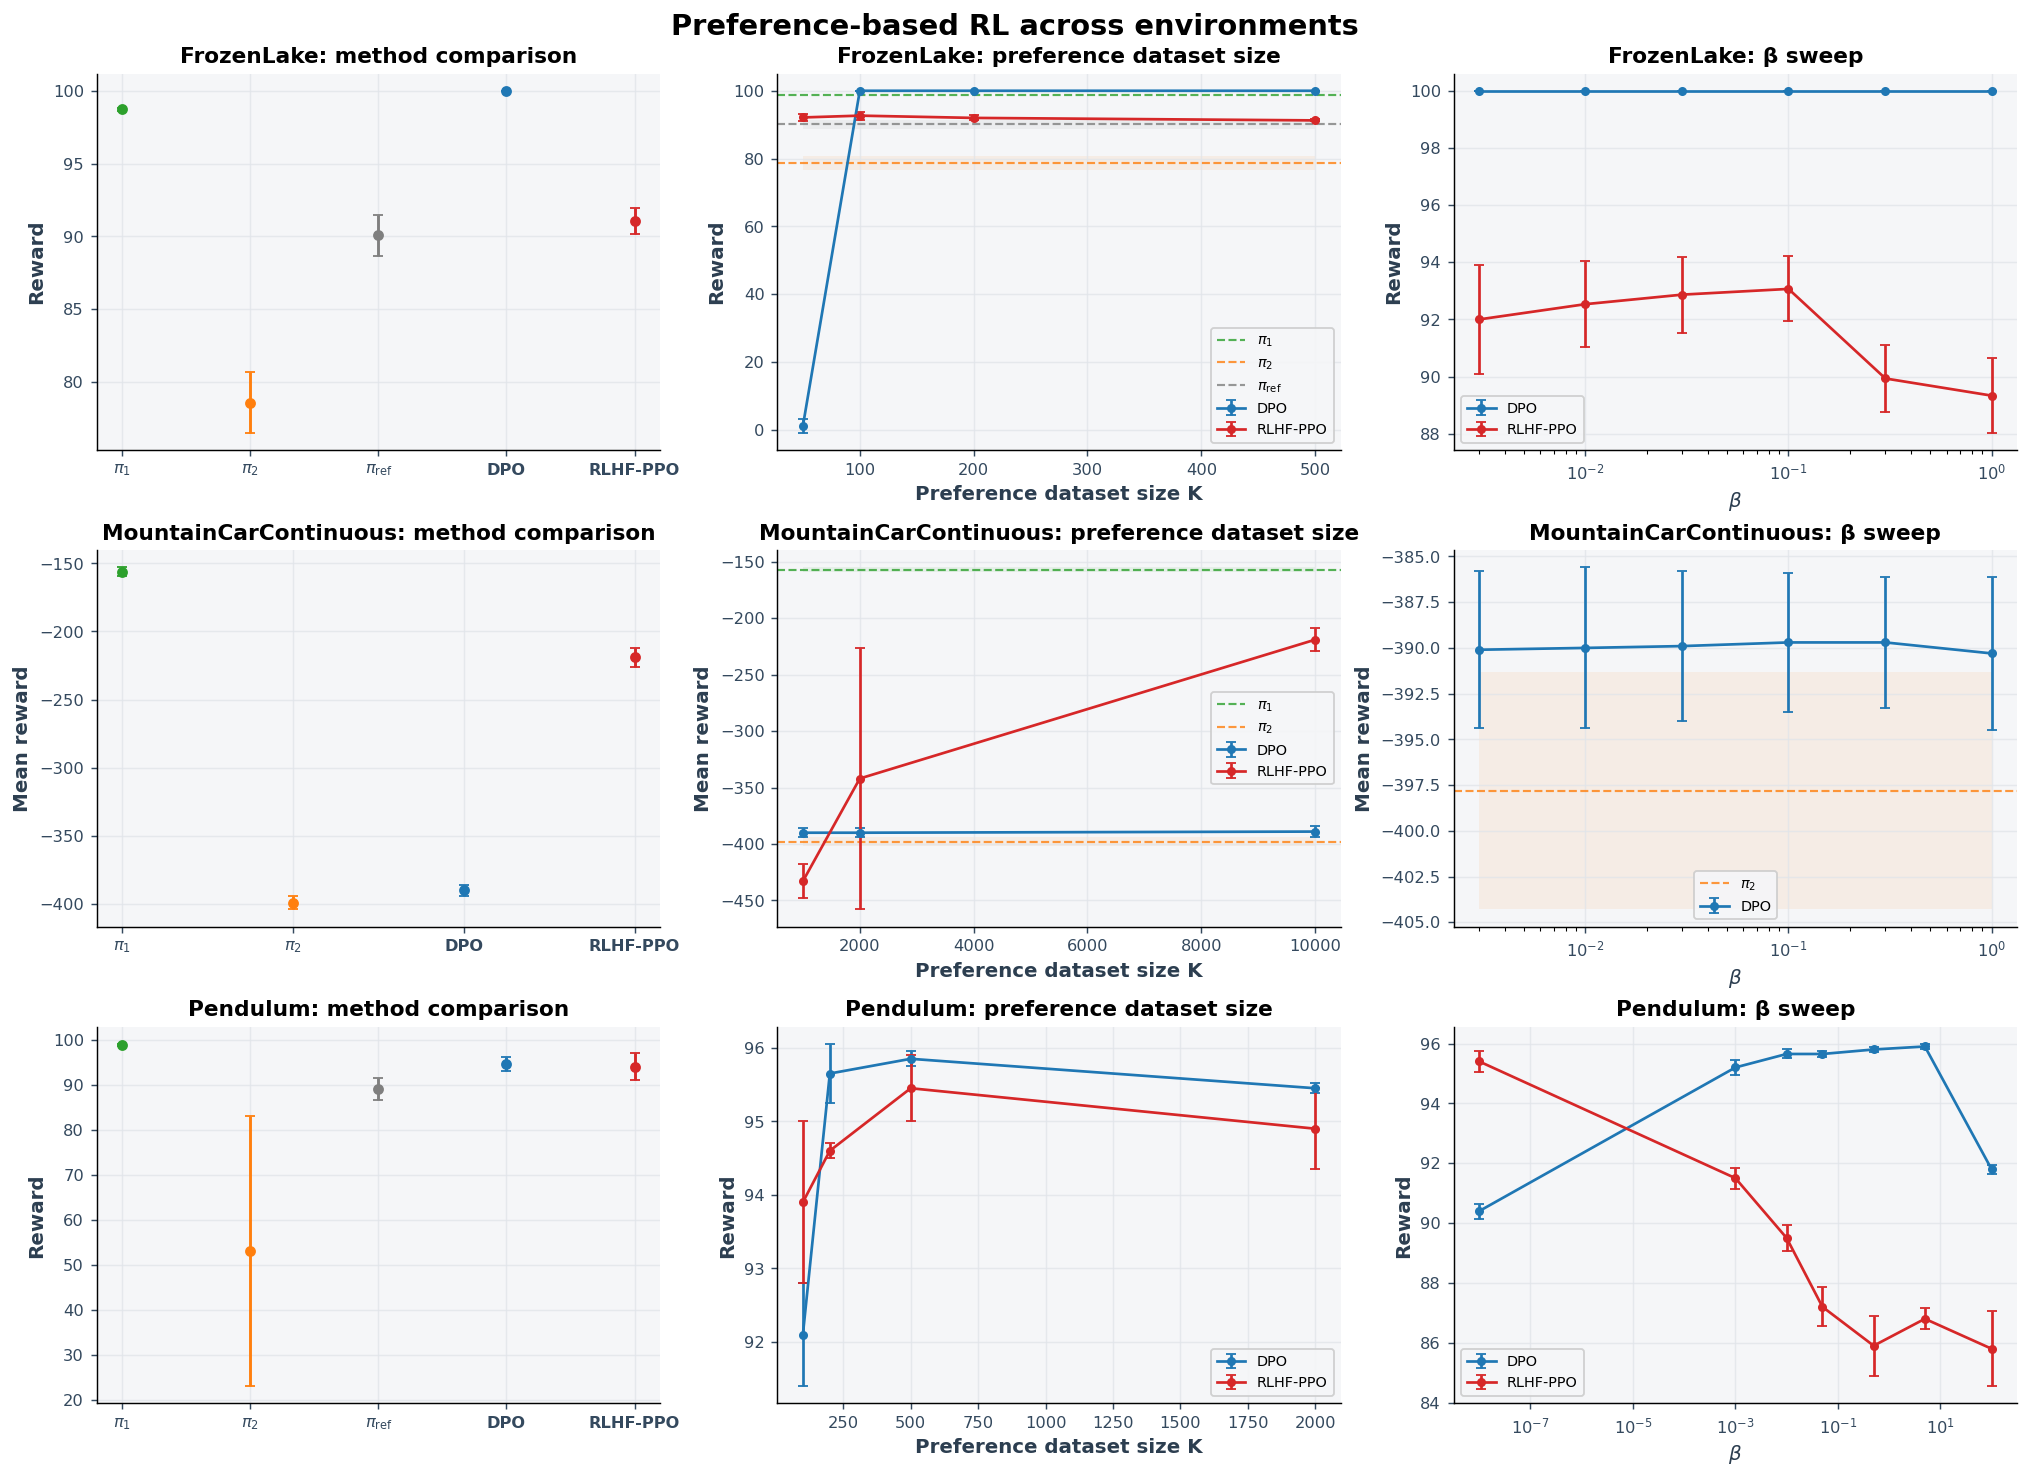

Saved: poster_rl_plots\rlhf_dpo_3env_3seeds.png
Saved: poster_rl_plots\rlhf_dpo_3env_3seeds.pdf


In [7]:

# FrozenLake summaries
fl_cmp, fl_k_x, fl_k_series, fl_beta_x, fl_beta_series = frozenlake_summaries(frozenlake_df)

fig, axes = plt.subplots(3, 3, figsize=(15.5, 11.0), constrained_layout=True)

# Row 1: FrozenLake
plot_comparison(
    axes[0, 0],
    fl_cmp,
    "FrozenLake: method comparison",
    ylabel="Reward"
)
plot_sweep(
    axes[0, 1],
    fl_k_x,
    fl_k_series,
    "FrozenLake: preference dataset size",
    xlabel="Preference dataset size K",
    ylabel="Reward",
    logx=False
)
plot_sweep(
    axes[0, 2],
    fl_beta_x,
    fl_beta_series,
    "FrozenLake: β sweep",
    xlabel=r"$\beta$",
    ylabel="Reward",
    logx=True,
    reference_as_band=False
)

# Row 2: MountainCarContinuous
mc = digitized["MountainCarContinuous"]
plot_comparison(
    axes[1, 0],
    mc["comparison"],
    "MountainCarContinuous: method comparison",
    ylabel="Mean reward"
)
plot_sweep(
    axes[1, 1],
    mc["K"]["x"],
    mc["K"]["series"],
    "MountainCarContinuous: preference dataset size",
    xlabel="Preference dataset size K",
    ylabel="Mean reward",
    logx=False
)
plot_sweep(
    axes[1, 2],
    mc["beta"]["x"],
    mc["beta"]["series"],
    "MountainCarContinuous: β sweep",
    xlabel=r"$\beta$",
    ylabel="Mean reward",
    logx=True
)

# Row 3: Pendulum
pend = digitized["Pendulum"]
plot_comparison(
    axes[2, 0],
    pend["comparison"],
    "Pendulum: method comparison",
    ylabel="Reward"
)
plot_sweep(
    axes[2, 1],
    pend["K"]["x"],
    pend["K"]["series"],
    "Pendulum: preference dataset size",
    xlabel="Preference dataset size K",
    ylabel="Reward",
    logx=False,
    reference_as_band=False
)
plot_sweep(
    axes[2, 2],
    pend["beta"]["x"],
    pend["beta"]["series"],
    "Pendulum: β sweep",
    xlabel=r"$\beta$",
    ylabel="Reward",
    logx=True,
    reference_as_band=False
)

for ax in axes.flat:
    ax.margins(x=0.05)

fig.suptitle("Preference-based RL across environments", fontsize=16, fontweight="bold", y=1.02)

png_path = OUT_DIR / "rlhf_dpo_3env_3seeds.png"
pdf_path = OUT_DIR / "rlhf_dpo_3env_3seeds.pdf"
fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")



###  FrozenLake raw results


In [8]:

display(frozenlake_df.head(20))

print("FrozenLake comparison summary")
display(fl_cmp)

print("FrozenLake K-sweep summary")
display(summarize(frozenlake_df[frozenlake_df["panel"] == "K"], ["method", "K"]))

print("FrozenLake beta-sweep summary")
display(summarize(frozenlake_df[frozenlake_df["panel"] == "beta"], ["method", "beta"]))


,env,panel,method,seed,K,beta,reward
0,FrozenLake,comparison,$\pi_1$,0,NaN,NaN,98.8
1,FrozenLake,comparison,$\pi_2$,0,NaN,NaN,79.8
2,FrozenLake,comparison,$\pi_{\mathrm{ref}}$,0,NaN,NaN,91.4
3,FrozenLake,comparison,DPO,0,200.0,0.100,100.0
4,FrozenLake,comparison,RLHF-PPO,0,200.0,0.030,92.0
5,FrozenLake,K,DPO,0,50.0,0.100,0.0
6,FrozenLake,K,RLHF-PPO,0,50.0,0.030,91.8
7,FrozenLake,K,DPO,0,100.0,0.100,100.0
8,FrozenLake,K,RLHF-PPO,0,100.0,0.030,92.2
9,FrozenLake,K,DPO,0,200.0,0.100,100.0


FrozenLake comparison summary


,method,mean,std
0,$\pi_1$,98.733333,0.115470
1,$\pi_2$,78.600000,2.078461
2,$\pi_{\mathrm{ref}}$,90.066667,1.404754
3,DPO,100.000000,0.000000
4,RLHF-PPO,91.066667,0.901850


FrozenLake K-sweep summary


,method,K,mean,std
0,DPO,50.0,1.133333,1.962991
1,DPO,100.0,100.000000,0.000000
2,DPO,200.0,100.000000,0.000000
3,DPO,500.0,100.000000,0.000000
4,RLHF-PPO,50.0,92.133333,0.945163
5,RLHF-PPO,100.0,92.666667,1.171893
6,RLHF-PPO,200.0,92.000000,0.721110
7,RLHF-PPO,500.0,91.266667,0.305505


FrozenLake beta-sweep summary


,method,beta,mean,std
0,DPO,0.003,100.000000,0.000000
1,DPO,0.010,100.000000,0.000000
2,DPO,0.030,100.000000,0.000000
3,DPO,0.100,100.000000,0.000000
4,DPO,0.300,100.000000,0.000000
5,DPO,1.000,100.000000,0.000000
6,RLHF-PPO,0.003,92.000000,1.907878
7,RLHF-PPO,0.010,92.533333,1.514376
8,RLHF-PPO,0.030,92.866667,1.331666
9,RLHF-PPO,0.100,93.066667,1.137248
